# Notebook 62 — Demonstrating the contraction toward a pile-up mass

**Goal.** Argue rigorously, against an astronomer-sceptic, that the $\sim 35\,M_\odot$ pile-up of CHE-derived BHs is **not fine-tuning** but the consequence of two pieces of independently-calibrated physics: the wind recipe `che_wind` (Vink/Bjorklund/Krticka/Sander stitch) and MESA's standard stellar-structure response. The argument is split in two:

1. **Part II — that a contraction occurs.** Show, from raw MESA grid endpoints, that $|\mathrm{d}M_f/\mathrm{d}M_i|\ll 1$ over a wide initial-mass range — a *finite-time trajectory contraction*.
2. **Parts III–IV — why at this mass.** Reduce the nominally 5-input wind law $\dot M(M, L, T_\mathrm{eff}, X_\mathrm{surf}, Z)$ to a 1-D potential-like quantity $\Phi(M; \theta, Z)$ on the WR phase by composing it with MESA-derived structure relations $L(M,\theta,Z)$, $T_\mathrm{eff}(M,\theta,Z)$, $X_\mathrm{surf}(M,\theta,Z)$; show that the locus $\Phi=0$ coincides with the observed MESA pile-up; and stress-test by re-evaluating across the wind variants 02–12 to see how rigid the locus is.


## 0. Setup

In [1]:
nb_id = 62

from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm, TwoSlopeNorm
from matplotlib.lines import Line2D
import mesa_reader as mr

import sys
sys.path.append('..')
from src.util import DATA_DIR, MESA_DATA_DIR, load_models2, savefig_base
from src.constants import Z_SUN

plt.style.use('./plotstyle.mplstyle')
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

# ── notebook-level settings ───────────────────────────────────────────────────
CUT_MISMATCHES = True   # drop runs whose inlist_both new_Z != Z encoded in folder name

# Z keys present in fiducial v6 file
Z_KEYS = ['0.0200', '0.0400', '0.0800', '0.1000', '0.2000', '0.3000', '0.4000']
Z_DIV_ZSUN = np.array([float(z) for z in Z_KEYS])


---

## Part I — Conceptual framework

### I.1 What "attractor" means rigorously

For an autonomous flow $\dot x = f(x)$ on a manifold $X$, an **attractor** is a compact invariant set $A\subset X$ admitting an open neighbourhood $U\supset A$ (its **basin**) with

$$
\omega(x)\subset A \quad\forall\,x\in U,
\qquad
\bigcap_{t\geq 0}\varphi_t(\overline U) = A.
$$

There are essentially three rigorous machineries used to *prove* such an $A$ exists:

1. **Lyapunov function.** Find $V:U\to\mathbb{R}_{\geq0}$ with $V|_A=0$, $V>0$ on $U\setminus A$, and $\dot V = \nabla V\cdot f < 0$ on $U\setminus A$. LaSalle's invariance principle relaxes the strict inequality.
2. **Trapping region (Conley).** Find a compact $N$ with $\varphi_t(N)\subset \mathrm{int}(N)$ for all $t>0$ — equivalently, $f$ pointing strictly inward on $\partial N$. Then $A := \bigcap_{t\geq 0}\varphi_t(N)$ is an attractor inside $N$.
3. **Contraction (Lohmiller–Slotine).** Show the symmetric part of the Jacobian, $\tfrac12(Df+Df^\top)$, is uniformly negative-definite under some metric. Then *any* two trajectories satisfy $\|x_1(t)-x_2(t)\|\leq e^{-\lambda t}\|x_1(0)-x_2(0)\|$, proving the existence of a single-trajectory attractor without identifying it explicitly.

### I.2 Why our system is **not** a dynamical-systems attractor

The CHE WR-phase mass evolution is

$$
\frac{\mathrm{d}M}{\mathrm{d}t} = -\dot M_S\bigl(M,t,Z\bigr),\qquad t\in[0,\,\tau_S(M_i,Z)].
$$

There is no $t\to\infty$ limit (the integration ends at He depletion / C depletion), no invariant set, no basin. Calling the cluster of $M_\mathrm{end}$ values an "attractor" is metaphorical, and that — I believe — is the source of nb61's Option C feeling unsatisfying: the quantity $y=\dot M\, t_\mathrm{rem}/M$ is forced to $0$ at the endpoint by construction.

The honest concept is **finite-time trajectory contraction**: the time-$\tau_S$ flow map $\Phi: M_i\mapsto M_f$ has Jacobian $|\Phi'(M_i)|\ll 1$ on a wide range of $M_i$.

### I.3 The contraction Jacobian

Linearising $\dot M = -\dot M_S(M,t,Z)$ around a fiducial trajectory and using the fact that the integration limit $\tau_S$ itself depends on $M_i$,

$$
\boxed{\;
\frac{\mathrm{d}M_f}{\mathrm{d}M_i}
= \exp\!\left[-\int_0^{\tau_S(M_i,Z)} \frac{\partial \dot M_S}{\partial M}\,\mathrm{d}t\right]
\;-\; \dot M_S\!\bigl(M_f,\tau_S,Z\bigr)\,\frac{\mathrm{d}\tau_S}{\mathrm{d}M_i}.
\;}
$$

For the toy power-law model $\dot M_S = \dot M_r m^\beta \zeta^\gamma$, $\tau_S = \tau_r m_i^{-\alpha}$ from nb70_REWRITE, this reduces analytically to your $\beta>\alpha+A$ condition, with $A$ a quantitative contraction rate rather than a heuristic threshold. The toy lives in the appendix; in Part II we evaluate $\mathrm{d}M_f/\mathrm{d}M_i$ directly from the MESA grid by finite differences.

### I.4 The two questions

1. **Does the contraction occur?** Equivalent to $\log_{10}|\mathrm{d}M_f/\mathrm{d}M_i| \ll 0$ on a wide $M_i$ band. Answered in Part II from raw MESA endpoints.
2. **Why at this particular $M_*$?** The 5-D wind law $\dot M(M,L,T_\mathrm{eff},X_\mathrm{surf},Z)$ does not, by itself, pick out a mass — the inputs are coupled by stellar structure. On the He-burning main sequence, MESA's structure equations produce tight relations $L(M,\theta,Z)$, $T_\mathrm{eff}(M,\theta,Z)$, $X_\mathrm{surf}(M,\theta,Z)$ with $\theta = t/\tau_\mathrm{WR}$. Composing the wind recipe with these relations collapses the dynamics to an effective $\dot M_\mathrm{eff}(M,\theta,Z)$. The fixed point is set by

$$
\Phi(M;\theta,Z) := \log_{10}\!\left[\frac{\dot M_\mathrm{eff}(M,\theta,Z)\,\tau_\mathrm{WR}(M,Z)}{M}\right]
= \log_{10}\!\left[\frac{\tau_\mathrm{WR}(M,Z)}{\tau_\mathrm{wind}(M,\theta,Z)}\right]
$$

with the pile-up locus given by $\Phi=0$ (winds and lifetime balance). Parts III–IV evaluate $\Phi$ from a Python transcription of `che_wind` composed with MESA-extracted structure relations, *per metallicity*.


---

## Part II — The contraction, demonstrated from MESA

Load the fiducial v6 grid endpoints and isolate CHE non-mergers reaching He depletion. We then look at the $M_f$ vs $M_i$ map per metallicity, and compute the finite-difference contraction Jacobian $|\mathrm{d}M_f/\mathrm{d}M_i|$ along the median final-mass trend in $M_i$ at fixed $Z$.


In [2]:
# Load fiducial endpoints (v6 schema)
core_props_df = pd.read_hdf(DATA_DIR / '00_fiducial_core_props_df.h5')
print('total rows:', len(core_props_df), '  cols:', core_props_df.shape[1])

# ── mismatch filter ───────────────────────────────────────────────────────────
_FIDUCIAL_Z_FOLDERS = {
    '0.0200': '0002_ZdivZsun_2d-02',
    '0.0400': '0003_ZdivZsun_4d-02',
    '0.0800': '0004_ZdivZsun_8d-02',
    '0.1000': '0005_ZdivZsun_1d-01',
    '0.2000': '0006_ZdivZsun_2d-01',
    '0.3000': '0007_ZdivZsun_3d-01',
    '0.4000': '0008_ZdivZsun_4d-01',
}

def _read_new_z_from_inlist(run_path):
    """Parse new_Z from run_path/inlist_both. Returns float or None on failure."""
    inlist = run_path / 'inlist_both'
    if not inlist.exists():
        return None
    try:
        with open(inlist) as f:
            for line in f:
                s = line.split('!', 1)[0].strip()
                if not s or '=' not in s:
                    continue
                key, _, val = s.partition('=')
                if key.strip() == 'new_Z':
                    return float(val.strip().split()[0].replace('d', 'e').replace('D', 'e'))
    except Exception:
        return None
    return None

def build_mismatch_mask(df):
    """Return a boolean Series (same index as df) marking rows whose run's
    inlist_both new_Z does not match the Z encoded in the metallicity folder name.
    Checks one run per (z_key, m_zams) group for efficiency (~168 inlist reads).
    """
    base = Path(MESA_DATA_DIR) / '00_fiducial'
    bad_pairs = set()
    for (z_key, m_zams), _ in df.groupby(['z_key', 'm_zams']):
        folder_name = _FIDUCIAL_Z_FOLDERS.get(str(z_key))
        if folder_name is None:
            continue
        expected_z = float(z_key) * Z_SUN
        m_int = int(round(float(m_zams)))
        mass_dirs = sorted((base / folder_name).glob(f'[0-9][0-9][0-9]_m{m_int}'))
        if not mass_dirs:
            continue
        run_dirs = [r for r in mass_dirs[0].glob('m*_p*_w*') if r.is_dir()]
        if not run_dirs:
            continue
        actual_z = _read_new_z_from_inlist(run_dirs[0])
        if actual_z is None or not np.isclose(actual_z, expected_z, rtol=1e-3, atol=0):
            bad_pairs.add((str(z_key), float(m_zams)))
    return pd.Series(
        [(str(r.z_key), float(r.m_zams)) in bad_pairs for r in df.itertuples()],
        index=df.index,
    )

if CUT_MISMATCHES:
    _mismatch = build_mismatch_mask(core_props_df)
    n_cut = int(_mismatch.sum())
    core_props_df = core_props_df[~_mismatch].reset_index(drop=True)
    print(f'CUT_MISMATCHES: dropped {n_cut} rows with wrong inlist Z '
          f'({len(core_props_df)} rows remaining)')

# CHE non-merger, reached at least He depletion (preferably C depletion)
mask = (
    core_props_df['is_che']
    & ~core_props_df['is_merger_at_zams']
    & ~core_props_df['is_l2of_at_zams']
    & ~core_props_df['is_crash']
    & core_props_df['is_He_depleted']
)
sel = core_props_df[mask].copy()
print('CHE non-merger He-depleted rows:', len(sel))

# Final mass: prefer m_cdepl when available (C-depletion), else m_f
sel['m_end'] = np.where(sel['is_C_depleted'], sel['m_cdepl'], sel['m_f'])
# z_div_zsun as float for plotting convenience
sel['z_zsun'] = sel['z_key'].astype(float)


total rows: 6719   cols: 171
CUT_MISMATCHES: dropped 1360 rows with wrong inlist Z (5359 rows remaining)
CHE non-merger He-depleted rows: 1433


### II.1 Final-vs-initial mass per metallicity

Each panel: scatter of $M_f$ against $M_i$ for one metallicity, with the IMF-weighted-irrelevant 1-to-1 line for reference. The flattening of the cloud at high $M_i$ is the contraction.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


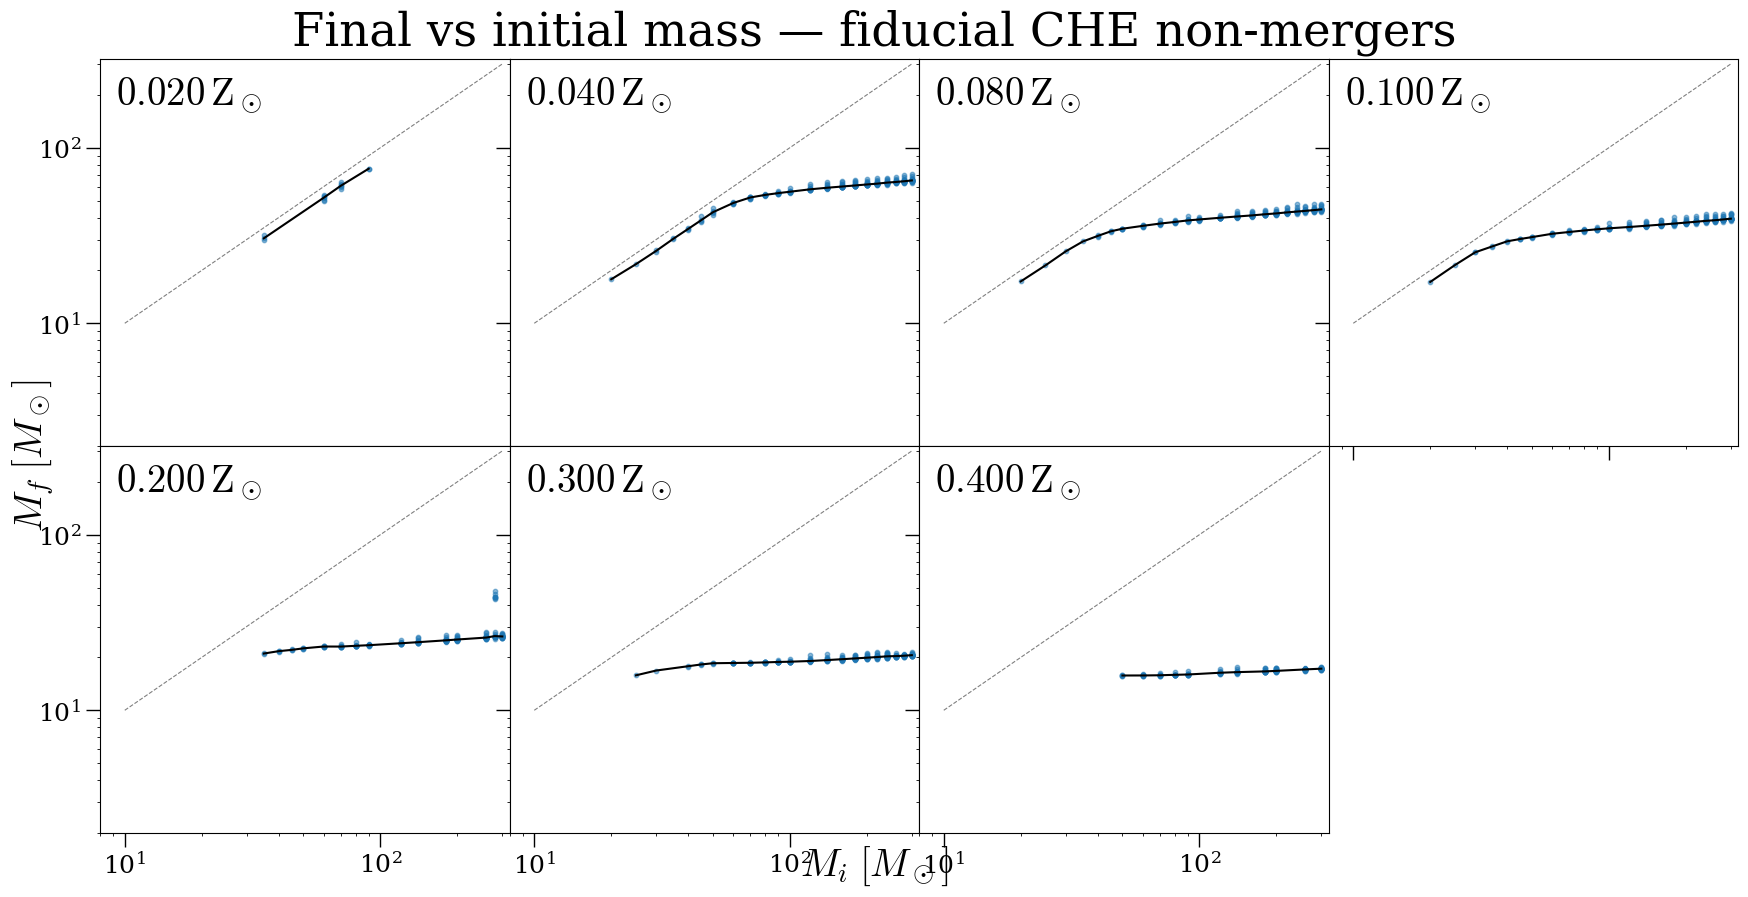

In [3]:
def per_z_panels(z_keys, plot_func, ncols=4, figsize=(18, 9),
                 sharex=True, sharey=True, xlabel=None, ylabel=None, suptitle=None):
    # Multi-panel grid with zero whitespace; per-axis labels suppressed,
    # single fig.text labels used instead.
    n = len(z_keys)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=sharex, sharey=sharey,
                             gridspec_kw={'wspace': 0, 'hspace': 0}, squeeze=False)
    axes_flat = axes.flatten()
    for i, z in enumerate(z_keys):
        plot_func(axes_flat[i], z)
        axes_flat[i].text(0.04, 0.96, rf'${float(z):.3f}\,\mathrm{{Z}}_\odot$',
                          ha='left', va='top', transform=axes_flat[i].transAxes)
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')
    if xlabel:
        fig.text(0.5, 0.02, xlabel, ha='center', va='bottom')
    if ylabel:
        fig.text(0.02, 0.5, ylabel, ha='left', va='center', rotation=90)
    if suptitle:
        fig.suptitle(suptitle, y=0.995)
    fig.subplots_adjust(left=0.07, right=0.98, bottom=0.08, top=0.94)
    return fig, axes_flat


def plot_mf_mi(ax, z):
    sub = sel[sel['z_key'] == z]
    sub_sorted = sub.sort_values('m_zams')
    ax.scatter(sub_sorted['m_zams'], sub_sorted['m_end'], s=10, alpha=0.5, color='C0')
    med = sub_sorted.groupby('m_zams')['m_end'].median()
    ax.plot(med.index, med.values, color='k', lw=1.5, label='median')
    mvals = np.array([10, 300])
    ax.plot(mvals, mvals, '--', color='gray', lw=0.8, label='$M_f=M_i$')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(8, 320); ax.set_ylim(2, 320)

fig, _ = per_z_panels(Z_KEYS, plot_mf_mi,
                      xlabel=r'$M_i\;[M_\odot]$', ylabel=r'$M_f\;[M_\odot]$',
                      suptitle=r'Final vs initial mass — fiducial CHE non-mergers')
savefig(fig, 'mf_vs_mi_perZ')
plt.show()


### II.2 Contraction Jacobian $|\mathrm{d}M_f/\mathrm{d}M_i|$ from MESA

Compute $\mathrm{d}M_f/\mathrm{d}M_i$ by finite differences on the median $M_f(M_i)$ curve at each $Z$. Plot $\log_{10}|\mathrm{d}M_f/\mathrm{d}M_i|$ vs $M_i$. The shaded band ($\log_{10}<-1$) marks one decade of contraction — *any* $M_i$ band falling in there compresses by $\geq 10\times$ on its way to $M_f$.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


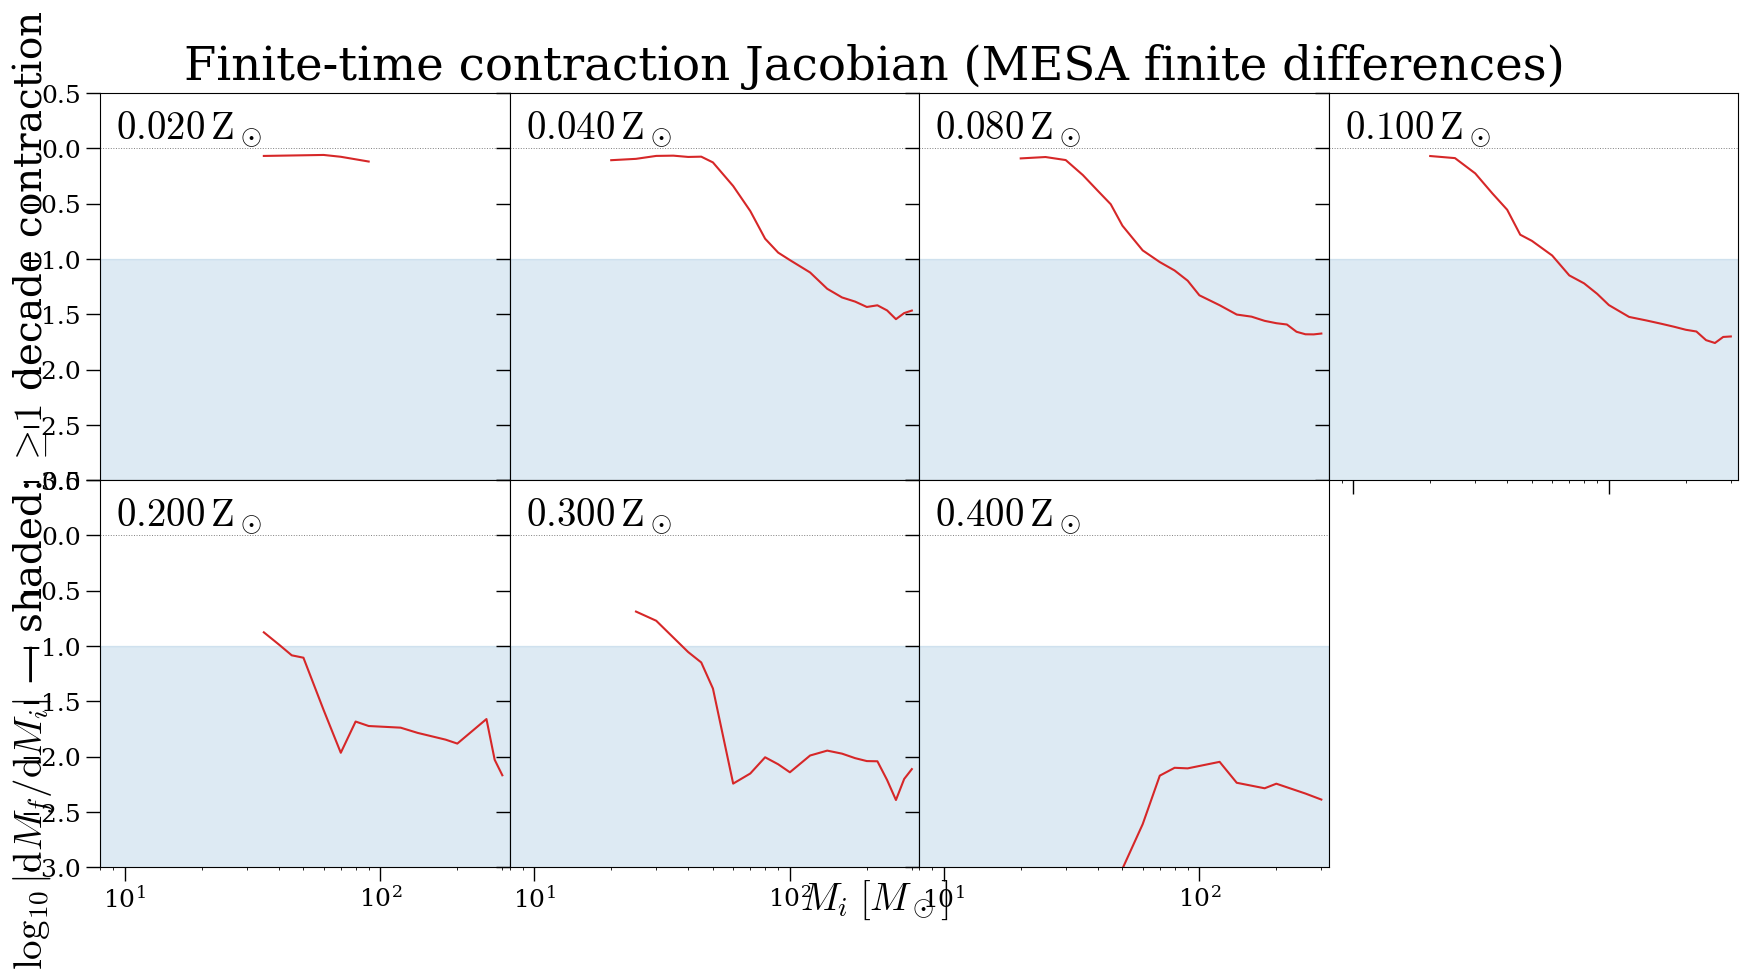

In [4]:
def median_mf_curve(z, m_min=10, m_max=300):
    sub = sel[sel['z_key'] == z].sort_values('m_zams')
    med = sub.groupby('m_zams')['m_end'].median().reset_index()
    med = med[(med['m_zams'] >= m_min) & (med['m_zams'] <= m_max)]
    return med['m_zams'].values, med['m_end'].values


def plot_jacobian(ax, z):
    mi, mf = median_mf_curve(z)
    if len(mi) < 3:
        return
    dmf_dmi = np.gradient(mf, mi)
    log_jac = np.log10(np.abs(dmf_dmi) + 1e-30)
    ax.axhspan(-5, -1, color='C0', alpha=0.15)
    ax.axhline(0, color='gray', ls=':', lw=0.7)
    ax.plot(mi, log_jac, color='C3', lw=1.5)
    ax.set_xscale('log')
    ax.set_xlim(8, 320); ax.set_ylim(-3.0, 0.5)

fig, _ = per_z_panels(Z_KEYS, plot_jacobian,
                      xlabel=r'$M_i\;[M_\odot]$',
                      ylabel=r'$\log_{10}|\mathrm{d}M_f/\mathrm{d}M_i|$ — shaded: $\geq 1$ decade contraction',
                      suptitle=r'Finite-time contraction Jacobian (MESA finite differences)')
savefig(fig, 'jacobian_perZ')
plt.show()


**Reading.** Wherever the red curve dips well below $0$, the time-$\tau_S$ flow $\Phi:M_i\mapsto M_f$ is *contracting* on that initial-mass band — a wide $M_i$ interval is mapped onto a narrow $M_f$ interval. That is the rigorous statement behind the "pile-up". The depth and width of the dip *quantify* the contraction; their location in $M_i$ determines what mass band ends up in the pile-up. This figure answers question I.4.1 (does the contraction occur?) without invoking any analytical model.


---

## Part III — Why at this mass: $\Phi(M;\theta,Z)$

### III.1 Strategy

`che_wind` (`run_star_extras.f90`, lines 574–900) takes 5 surface variables: $(M, L, T_\mathrm{eff}, X_\mathrm{surf}, Z)$. In isolation those are 5 independent inputs — the wind law is a hypersurface in 6-D. The reason the system has a fixed mass scale is **not** that the wind law alone selects one: it is that MESA's structure equations (hydrostatic + thermal equilibrium + opacity + nuclear network) impose tight relations among $L$, $T_\mathrm{eff}$, $X_\mathrm{surf}$ and $M$ on the He-burning main sequence, parametrised by progress $\theta := (t-t_\mathrm{WR})/\tau_\mathrm{WR} \in [0,1]$.

Composing the recipe with these MESA-given relations,

$$
\dot M_\mathrm{eff}(M,\theta,Z) := \dot M_\mathrm{wind}\!\bigl(M,\,L_\mathrm{HeMS}(M,\theta,Z),\,T_\mathrm{eff,HeMS}(M,\theta,Z),\,X_\mathrm{surf,HeMS}(M,\theta,Z),\,Z\bigr),
$$

we get a function of just $(M,\theta,Z)$. At fixed $Z$ this is 2-D and can be drawn as a potential-like background with the actual MESA $M(t)$ trajectories overlaid.

### III.2 Python transcription of `che_wind`

We transcribe the relevant fortran subroutines literally, with units in (Lsun, Msun, K, mass-fraction, $Z$ absolute). Production fiducial settings: `wind_scheme = 'bjorklund+krticka'`, `vms_wind_transition_scheme = 'bjorklund+krticka'`, `X0=0.6, dX=0.3, beta=gamma=0, Mdot_r=1.0`. Inconsistencies vs `src/winds.py` are logged in `WIND_CORRECTIONS.md`.


In [5]:
# ---- che_wind transcription (units: Lsun, Msun, K, mass-fraction, Z absolute) ----
ZSUN_LOC = 0.017  # match fortran exactly (s. che_wind line 594)


def edd_gamma_mesa(L_Lsun, M_Msun, X):
    # fortran line 610: G_e = 10**-4.813 * (1+X) * (Lsurf/Lsun)/(Msurf/Msun)
    return 10.0**(-4.813) * (1.0 + X) * L_Lsun / M_Msun


def vink2001_w(L_Lsun, M_Msun, Teff_K, Z):
    Z_div_Zsun = Z / ZSUN_LOC
    Teff_jump = 1e3 * (61.2 + 2.59*(-13.636 + 0.889*np.log10(Z_div_Zsun)))
    if Teff_K > 27.5e3:
        a = 1.0
    elif Teff_K < 22.5e3:
        a = 0.0
    else:
        dT = 100.0
        if Teff_K > Teff_jump + dT: a = 1.0
        elif Teff_K < Teff_jump - dT: a = 0.0
        else: a = (Teff_K - (Teff_jump - dT)) / (2*dT)
    if a > 0:
        vinf_div_vesc = 2.6 * (Z_div_Zsun)**0.13
        log_mdot1 = (-6.697 + 2.194*np.log10(L_Lsun/1e5) - 1.313*np.log10(M_Msun/30.0)
                     - 1.226*np.log10(vinf_div_vesc/2.0) + 0.933*np.log10(Teff_K/4e4)
                     - 10.92*np.log10(Teff_K/4e4)**2 + 0.85*np.log10(Z/ZSUN_LOC))
        mdot1 = 10.0**log_mdot1
    else:
        mdot1 = 0.0
    if a < 1:
        vinf_div_vesc = 1.3 * (Z_div_Zsun)**0.13
        log_mdot2 = (-6.688 + 2.210*np.log10(L_Lsun/1e5) - 1.339*np.log10(M_Msun/30.0)
                     - 1.601*np.log10(vinf_div_vesc/2.0) + 1.07*np.log10(Teff_K/2e4)
                     + 0.85*np.log10(Z/ZSUN_LOC))
        mdot2 = 10.0**log_mdot2
    else:
        mdot2 = 0.0
    return a*mdot1 + (1 - a)*mdot2


def bjorklund2023_w(L_Lsun, M_Msun, Teff_K, Z, X):
    Ge = edd_gamma_mesa(L_Lsun, M_Msun, X)
    Meff = M_Msun * (1.0 - Ge)
    if Meff <= 0: return 0.0
    log_mdot = (-5.52 + 2.39*np.log10(L_Lsun/1e6) - 1.48*np.log10(Meff/45.0)
                + 2.12*np.log10(Teff_K/4.5e4)
                + (0.75 - 1.87*np.log10(Teff_K/4.5e4)) * np.log10(Z/ZSUN_LOC))
    return 10.0**log_mdot


def krticka2024_w(L_Lsun, Teff_K, Z):
    log_Z = np.log10(Z / ZSUN_LOC)
    log_lin = -13.82 + 0.358*log_Z + (1.52 - 0.11*log_Z) * np.log10(L_Lsun/1e6)
    # fortran: gaussian_mix_term = (1+0.73*log_Z) * exp(-(T-1.416e4)^2/(3.58e3)^2 [as written; see f90])
    # Reading the fortran literally: first term has missing parens — uses pow2(Tsurf-1.416d4)/pow2(3.58d3)
    # divided not multiplied is implied by exp(-pow2(...))/pow2(...). We follow the literal fortran.
    g_mix = ((1.0 + 0.73*log_Z) * np.exp(-(Teff_K - 1.416e4)**2 / (3.58e3)**2)
             + 3.84 * np.exp(-(Teff_K - 3.79e4)**2 / (5.65e4)**2))
    if g_mix <= 0: return 0.0
    return 10.0**(log_lin + 13.82*np.log10(g_mix))


def G_switch_value(Z, vms_scheme, krt_w=None, bjo_w=None):
    z = Z / ZSUN_LOC
    if vms_scheme == 'vink':       return 0.243 * z**(-0.541)
    if vms_scheme == 'krticka':    return 0.585 * z**(-0.016)
    if vms_scheme == 'bjorklund':  return 0.838 * z**(-0.099)
    if vms_scheme == 'bjorklund+krticka':
        if krt_w is None or bjo_w is None:
            return 0.838 * z**(-0.099)
        return 0.585*z**(-0.016) if krt_w <= bjo_w else 0.838*z**(-0.099)
    raise ValueError(vms_scheme)


def vink2017_w(L_Lsun, Z):
    return 10.0**(-13.3 + 1.36*np.log10(L_Lsun) + 0.61*np.log10(Z/ZSUN_LOC))


def sander2023_w(L_Lsun, Teff_K, Z):
    logz = np.log10(Z / ZSUN_LOC)
    alpha = 0.32*logz + 1.4
    l0 = 10.0**(-0.87*logz + 5.06)
    mdot10 = 10.0**(-0.75*logz - 4.06)
    if L_Lsun < l0:
        log_pow = 0.0
        w = 0.0
    else:
        log_pow = np.log10(L_Lsun/l0)**alpha
        w = mdot10 * log_pow * (L_Lsun/l0/10.0)**0.75
        if Teff_K > 1e5 and L_Lsun > l0:
            w = 10.0**(np.log10(w) - 6*np.log10(Teff_K/1.41e5))
    return w


def che_wind(M_Msun, L_Lsun, Teff_K, X, Z,
             X0=0.6, dX=0.3, beta_extra=0.0, gamma_extra=0.0, mdot_r_extra=1.0,
             wind_scheme='bjorklund+krticka', vms_scheme='bjorklund+krticka',
             M_switch=None):
    # Return |dM/dt| in Msun/yr. Mirrors run_star_extras.f90:che_wind.
    Z_div_Zsun = Z / ZSUN_LOC
    # He-poor thin
    if wind_scheme == 'vink':
        thin = vink2001_w(L_Lsun, M_Msun, Teff_K, Z)
    elif wind_scheme == 'bjorklund':
        thin = bjorklund2023_w(L_Lsun, M_Msun, Teff_K, Z, X)
    elif wind_scheme == 'krticka':
        thin = krticka2024_w(L_Lsun, Teff_K, Z)
    elif wind_scheme == 'bjorklund+krticka':
        thin = min(bjorklund2023_w(L_Lsun, M_Msun, Teff_K, Z, X),
                   krticka2024_w(L_Lsun, Teff_K, Z))
    else:
        raise ValueError(wind_scheme)
    # G_switch and thick He-poor
    Ge = edd_gamma_mesa(L_Lsun, M_Msun, X)
    krt = krticka2024_w(L_Lsun, Teff_K, Z)
    bjo = bjorklund2023_w(L_Lsun, M_Msun, Teff_K, Z, X)
    Gsw = G_switch_value(Z, vms_scheme, krt_w=krt, bjo_w=bjo)
    v01 = vink2001_w(L_Lsun, M_Msun, Teff_K, Z)
    if Ge < Gsw:
        thick = v01
        he_poor_w = thin
    else:
        if M_switch is None:
            M_switch = M_Msun  # stand-in; fortran caches at first crossing
        thick = v01 * (M_Msun/M_switch)**0.78 * (Ge/Gsw)**4.77
        he_poor_w = thick
    # He-rich
    he_rich_w = max(vink2017_w(L_Lsun, Z), sander2023_w(L_Lsun, Teff_K, Z)) \
                * (M_Msun/30.0)**beta_extra * (Z_div_Zsun)**gamma_extra * mdot_r_extra
    # blend
    if X > X0:
        a = 1.0
    elif X > X0 - dX:
        a = (X - (X0 - dX)) / dX
    else:
        a = 0.0
    return a * he_poor_w + (1.0 - a) * he_rich_w


# Vectorised wrapper for grids
def che_wind_vec(M, L, Teff, X, Z, **kw):
    M = np.atleast_1d(M).astype(float)
    L = np.atleast_1d(L).astype(float)
    Teff = np.atleast_1d(Teff).astype(float)
    X = np.atleast_1d(X).astype(float)
    out = np.empty_like(M)
    for i in range(M.size):
        out.flat[i] = che_wind(M.flat[i], L.flat[i], Teff.flat[i], X.flat[i], Z, **kw)
    return out


### III.3 Validation — recompute $\dot M$ along a single MESA history

Pick one mid-grid CHE run, evaluate the Python `che_wind` along its $(M, L, T_\mathrm{eff}, X)$ history, and compare with MESA's `log_abs_mdot`. They must agree to within numerics.


period: 1.50 len: 4205


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


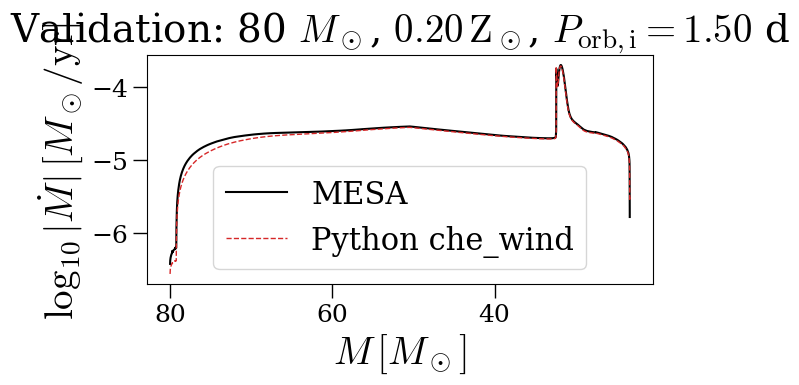

log10 residual: median=-0.014, MAD=0.005


In [6]:
def load_history(z_folder, mass_str, period_str=None):
    z_path = Path(MESA_DATA_DIR) / '00_fiducial' / z_folder
    models = load_models2(z_path)
    if mass_str not in models:
        return None
    if period_str is None:
        period_str = sorted(models[mass_str].keys())[len(models[mass_str])//2]
    p = models[mass_str][period_str]
    return mr.MesaData(str(Path(p) / 'LOGS/history.data')), period_str


def find_che_run(z_folder, target_mass='80.0'):
    # pick a CHE non-merger reaching He depletion at this Z and mass
    z_str = z_folder.split('_')[-1].replace('d-0','e-').replace('d+0','e+').replace('d0','')
    z_val = {'5d-03':0.005, '1d-02':0.01, '2d-02':0.02, '4d-02':0.04, '8d-02':0.08,
             '1d-01':0.10, '2d-01':0.20, '3d-01':0.30, '4d-01':0.40}[z_folder.split('_')[-1]]
    z_key = f'{z_val:.4f}'
    sub = sel[(sel['z_key']==z_key) & (np.isclose(sel['m_zams'].astype(float), float(target_mass)))]
    if len(sub) == 0: return None
    # take the run with the largest p_orb_zams (longest period within CHE)
    return sub.sort_values('p_orb_zams').iloc[len(sub)//2]


h, p_str = load_history('0006_ZdivZsun_2d-01', '80.0', '1.50')
print('period:', p_str, 'len:', len(h.star_age))

Z_abs = 0.20 * ZSUN_LOC  # Z/Zsun=0.20

# Restrict to post-ZAMS, before crash
ok = (h.log_abs_mdot > -50)
M = h.star_mass[ok]; L = 10**h.log_L[ok]; Teff = 10**h.log_Teff[ok]; X = h.surface_h1[ok]
mdot_mesa = 10**h.log_abs_mdot[ok]
mdot_py = che_wind_vec(M, L, Teff, X, Z_abs)

fig, ax = plt.subplots(1,1, figsize=(7,4.5))
ax.plot(M, np.log10(mdot_mesa), label='MESA', color='k', lw=1.5)
ax.plot(M, np.log10(mdot_py),   label='Python che_wind', color='C3', lw=1.0, ls='--')
ax.set_xlabel(r'$M\,[M_\odot]$'); ax.set_ylabel(r'$\log_{10}|\dot M|\,[M_\odot/\mathrm{yr}]$')
ax.set_title(rf'Validation: 80 $M_\odot$, $0.20\,\mathrm{{Z}}_\odot$, $P_\mathrm{{orb,i}}={p_str}$ d')
ax.invert_xaxis()
ax.legend()
fig.tight_layout()
savefig(fig, 'wind_validation_single')
plt.show()

# residual statistics
resid = np.log10(mdot_py) - np.log10(mdot_mesa)
print(f'log10 residual: median={np.median(resid):.3f}, MAD={np.median(np.abs(resid-np.median(resid))):.3f}')


If validation shows large residuals, the most likely cause is the M_switch caching: the fortran stores M at first G_e>G_switch crossing and reuses it; the Python recreates this only crudely. The fiducial CHE WR phase is mostly He-rich, where M_switch is irrelevant — residuals concentrate in the early thick-MS phase.

### III.4 He-MS structure relations from MESA histories

For each metallicity, extract $L$, $T_\mathrm{eff}$, $X_\mathrm{surf}$ along the WR phase ($Y_\mathrm{surf}\geq 0.6$, central H exhausted) of all CHE non-merger runs. Build empirical relations $L_\mathrm{HeMS}(M,Z)$, $T_\mathrm{eff,HeMS}(M,Z)$, $X_\mathrm{surf,HeMS}(M,Z)$ averaged over the WR-progress coordinate $\theta$, and also the $\theta$-resolved versions for finer evaluations. Also extract $\tau_\mathrm{WR}(M,Z)$ as the WR-phase duration as a function of *initial* WR mass.


In [7]:
# Parallel WR-phase track loader. CHE filter = reaches WR phase (surface_he4 >= HE4_ONSET);
# no other checks. ~3000 jobs across 60 cores ~= 1 min.
import concurrent.futures
from tqdm.notebook import tqdm

HE4_ONSET = 0.6   # x_ctrl(5) in the fortran wind scheme
N_CORES   = 30
# CUT_MISMATCHES is set at the top of the notebook (cell 0. Setup)

Z_FOLDERS = {
    '0.0200': '0002_ZdivZsun_2d-02',
    '0.0400': '0003_ZdivZsun_4d-02',
    '0.0800': '0004_ZdivZsun_8d-02',
    '0.1000': '0005_ZdivZsun_1d-01',
    '0.2000': '0006_ZdivZsun_2d-01',
    '0.3000': '0007_ZdivZsun_3d-01',
    '0.4000': '0008_ZdivZsun_4d-01',
}


# PeakDemo-style folder model dict — keyed by (m_str, p_str) parsed from folder names.
def _get_model_dict(grid_folder):
    d = {}
    for run in grid_folder.glob('m*_p*_w*'):
        if run.suffix == '.log' or not run.is_dir():
            continue
        m, p, w = run.name.replace('d', 'e').split('_')
        m_str = f'{float(m.lstrip("m")):.1f}'
        p_str = f'{float(p.lstrip("p")):.2f}'
        d.setdefault(m_str, {})[p_str] = run
    return d


def _model_dict_for_z(z_folder_name):
    base = Path(MESA_DATA_DIR) / '00_fiducial' / z_folder_name
    out = {}
    for grid in base.glob('[0-9][0-9][0-9]_m*'):
        for m_str, periods in _get_model_dict(grid).items():
            out.setdefault(m_str, {}).update(periods)
    return out


def _zdivzsun_from_folder(folder_name):
    """Parse Z/Zsun from a folder name like '0002_ZdivZsun_2d-02'."""
    return float(folder_name.split('ZdivZsun_')[1].replace('d', 'e'))


# CHE filter — copied verbatim from PeakDemo (uses p_spin_zams; folder period
# matches p_spin_zams not p_orb_zams because of tidal sync at ZAMS).
che_mask = (
    core_props_df['is_che']
    & core_props_df['is_He_depleted']
    & ~core_props_df['is_merger_at_zams']
    & ~core_props_df['is_l2of_at_zams']
    & ~core_props_df['is_crit_at_zams']
)
che_df = core_props_df[che_mask]
che_keys = set(zip(
    che_df.z_key.map(lambda s: round(float(s), 4)),
    che_df.m_zams.round(1),
    che_df.p_spin_zams.round(2),
))
print(f'{len(che_keys)} CHE+He-dep+non-merger+non-l2of+non-crit runs in core_props_df')


def _load_one_track(args):
    z_key, m_str, p_str, run_path, cut_mismatches = args
    if cut_mismatches:
        folder_name = run_path.parent.parent.name
        expected_z  = _zdivzsun_from_folder(folder_name) * Z_SUN
        actual_z    = _read_new_z_from_inlist(run_path)
        if actual_z is None or not np.isclose(actual_z, expected_z, rtol=1e-3, atol=0):
            return (z_key, None)
    hist = Path(run_path) / 'LOGS' / 'history.data'
    if not hist.exists():
        return (z_key, None)
    try:
        h = mr.MesaData(str(hist))
    except Exception:
        return (z_key, None)
    he4 = h.surface_he4
    wr = np.where(he4 >= HE4_ONSET)[0]
    if len(wr) < 5:
        return (z_key, None)
    i0 = int(wr[0])
    sl = slice(i0, len(he4))
    t = h.star_age[sl] - h.star_age[i0]
    if t[-1] <= 0:
        return (z_key, None)
    return (z_key, dict(
        M = h.star_mass[sl].copy(),
        L = (10.0**h.log_L[sl]).copy(),
        Teff = (10.0**h.log_Teff[sl]).copy(),
        X = h.surface_h1[sl].copy(),
        Y = he4[sl].copy(),
        t = t.copy(),
        tau_WR = float(t[-1]),
        m_wr_start = float(h.star_mass[sl][0]),
        log_abs_mdot = h.log_abs_mdot[sl].copy(),
        m_zams_folder = float(m_str),
        p_spin_folder = float(p_str),
    ))


jobs = []
for z_key, z_folder in Z_FOLDERS.items():
    zdivzsun = round(float(z_key), 4)
    md = _model_dict_for_z(z_folder)
    for m_str, periods in md.items():
        m = round(float(m_str), 1)
        for p_str, run_path in periods.items():
            p = round(float(p_str), 2)
            if (zdivzsun, m, p) in che_keys:
                jobs.append((z_key, m_str, p_str, run_path, CUT_MISMATCHES))
print(f'Submitting {len(jobs)} histories on {N_CORES} workers (cut_mismatches={CUT_MISMATCHES})...')

TRACKS = {z: [] for z in Z_KEYS}
with concurrent.futures.ProcessPoolExecutor(max_workers=N_CORES) as ex:
    futures = [ex.submit(_load_one_track, j) for j in jobs]
    for fut in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc='loading'):
        z_key, tr = fut.result()
        if tr is not None:
            TRACKS[z_key].append(tr)
for z, ts in TRACKS.items():
    print(f'  Z/Zsun={z}: {len(ts)} WR tracks')


1433 CHE+He-dep+non-merger+non-l2of+non-crit runs in core_props_df
Submitting 1433 histories on 30 workers (cut_mismatches=True)...


loading:   0%|          | 0/1433 [00:00<?, ?it/s]

  Z/Zsun=0.0200: 17 WR tracks
  Z/Zsun=0.0400: 249 WR tracks
  Z/Zsun=0.0800: 255 WR tracks
  Z/Zsun=0.1000: 266 WR tracks
  Z/Zsun=0.2000: 188 WR tracks
  Z/Zsun=0.3000: 282 WR tracks
  Z/Zsun=0.4000: 169 WR tracks


### III.5 Build He-MS structure relations $L(M,\theta,Z)$, $T_\mathrm{eff}(M,\theta,Z)$, $X(M,\theta,Z)$

Bin all WR tracks at a given $Z$ in the $(M_\mathrm{inst}, \theta)$ plane and take the median. This *is* the manifold on which the dynamics lives — derived without any analytical model.


In [8]:
def hems_relations(tracks, M_grid, theta_grid, dlogM=0.06, dtheta=0.07, min_pts=3):
    # Bin all WR-track samples by (M_inst, theta) with MULTIPLICATIVE M bins
    # (Δlog10 M ≈ dlogM) and additive theta bins. Returns medians on the grid.
    pts_logM, pts_theta, pts_L, pts_T, pts_X = [], [], [], [], []
    for tr in tracks:
        if tr['tau_WR'] <= 0: continue
        theta = tr['t'] / tr['tau_WR']
        pts_logM.append(np.log10(tr['M']))
        pts_theta.append(theta)
        pts_L.append(tr['L']); pts_T.append(tr['Teff']); pts_X.append(tr['X'])
    if not pts_logM:
        return None
    logM_arr = np.concatenate(pts_logM); theta_arr = np.concatenate(pts_theta)
    L_arr = np.concatenate(pts_L); T_arr = np.concatenate(pts_T); X_arr = np.concatenate(pts_X)
    L_grid = np.full((len(theta_grid), len(M_grid)), np.nan)
    T_grid = np.full_like(L_grid, np.nan)
    X_grid = np.full_like(L_grid, np.nan)
    logMg = np.log10(M_grid)
    for i, th in enumerate(theta_grid):
        sel_th = np.abs(theta_arr - th) < dtheta
        if not sel_th.any(): continue
        for j, lmm in enumerate(logMg):
            sel_M = np.abs(logM_arr - lmm) < dlogM
            both = sel_th & sel_M
            if both.sum() >= min_pts:
                L_grid[i,j] = np.median(L_arr[both])
                T_grid[i,j] = np.median(T_arr[both])
                X_grid[i,j] = np.median(X_arr[both])
    return L_grid, T_grid, X_grid


def tau_wr_from_tracks(tracks, M_grid, dlogM=0.1, min_pts=2):
    # tau_WR(M_start) median, binned by tracks' starting WR mass (multiplicative).
    starts = np.log10(np.array([tr['m_wr_start'] for tr in tracks]))
    taus = np.array([tr['tau_WR'] for tr in tracks])
    out = np.full_like(M_grid, np.nan, dtype=float)
    for j, mm in enumerate(M_grid):
        sel_b = np.abs(starts - np.log10(mm)) < dlogM
        if sel_b.sum() >= min_pts:
            out[j] = np.median(taus[sel_b])
    # forward/backward fill across NaN gaps so dense grid is usable
    fin = np.where(np.isfinite(out))[0]
    if len(fin) >= 2:
        out_fill = np.interp(np.arange(len(out)), fin, out[fin])
        # only fill within the data range
        mask = (np.arange(len(out)) >= fin.min()) & (np.arange(len(out)) <= fin.max())
        out = np.where(mask, out_fill, np.nan)
    return out

def t_rem_grid(tracks, M_grid, theta_grid, dlogM=0.06, dtheta=0.07, min_pts=2):
    """Median *remaining* WR time t_rem = tau_WR - t, binned by (M_inst, theta).
    Populates low-mass bins because tracks pass through them on the way down."""
    pts_logM, pts_theta, pts_trem = [], [], []
    for tr in tracks:
        if tr['tau_WR'] <= 0: continue
        theta = tr['t'] / tr['tau_WR']
        t_rem = tr['tau_WR'] - tr['t']
        pts_logM.append(np.log10(tr['M']))
        pts_theta.append(theta)
        pts_trem.append(t_rem)
    if not pts_logM:
        return None
    logM_arr = np.concatenate(pts_logM)
    theta_arr = np.concatenate(pts_theta)
    trem_arr = np.concatenate(pts_trem)
    out = np.full((len(theta_grid), len(M_grid)), np.nan)
    logMg = np.log10(M_grid)
    for i, th in enumerate(theta_grid):
        sel_th = np.abs(theta_arr - th) < dtheta
        if not sel_th.any(): continue
        for j, lmm in enumerate(logMg):
            sel_M = np.abs(logM_arr - lmm) < dlogM
            both = sel_th & sel_M
            if both.sum() >= min_pts:
                out[i,j] = np.median(trem_arr[both])
    return out


def compute_wr_slope_per_track(tracks_dict):
    """For each loaded track, fit theta = a + b*log10(M) over the WR phase
    and return (b, intercept_a, M_start, M_end, tau_WR) keyed by
    (z_div_zsun_rounded, m_zams_rounded, p_spin_rounded) — the same triple used
    by `che_keys` so the result joins onto core_props_df.

    b is the slope dtheta/dlog10(M); negative for tracks that lose mass
    monotonically over the WR phase (which is the normal case).
    """
    out = {}
    for z_key, tracks in tracks_dict.items():
        z_val = round(float(z_key), 4)
        for tr in tracks:
            M = tr['M']; theta = tr['t']/tr['tau_WR']
            mask = (M > 0) & np.isfinite(M) & np.isfinite(theta)
            if mask.sum() < 5: continue
            logM = np.log10(M[mask]); th = theta[mask]
            # least-squares linear fit
            b, a = np.polyfit(logM, th, 1)
            key = (z_val, round(tr['m_zams_folder'], 1), round(tr['p_spin_folder'], 2))
            out[key] = dict(slope=float(b), intercept=float(a),
                            M_start=float(M[0]), M_end=float(M[-1]),
                            tau_WR=float(tr['tau_WR']))
    return out


def add_wr_slope_column(core_df, slope_dict, col='wr_slope'):
    """Return a copy of core_df with a new `col` populated from slope_dict
    (NaN for rows that have no matching track)."""
    df = core_df.copy()
    keys = list(zip(
        df['z_key'].map(lambda s: round(float(s), 4)),
        df['m_zams'].astype(float).round(1),
        df['p_spin_zams'].astype(float).round(2),
    ))
    df[col] = [slope_dict.get(k, {}).get('slope', np.nan) for k in keys]
    return df


def split_by_wr_slope(df_with_slope, threshold, col='wr_slope'):
    """Return (df_steeper, df_shallower) where 'steeper' means more negative
    slope (faster mass loss per unit log M) than `threshold`."""
    s = df_with_slope[col]
    return (
        df_with_slope[s < threshold].copy(),
        df_with_slope[s >= threshold].copy(),
    )


### III.6 The potential $\Phi(M;\theta,Z)$ and per-$Z$ panels

Define on the WR phase

$$\Phi(M;\theta,Z) \;:=\; \log_{10}\!\left[\frac{\dot M_\mathrm{eff}(M,\theta,Z)\,\tau_\mathrm{WR}(M,Z)}{M}\right],$$

i.e., the log of the fraction of the current mass that the *current* wind would remove over a full WR lifetime starting at the current mass. Per metallicity, plot $\Phi$ on the $(M, \theta)$ plane with $\theta=t/\tau_\mathrm{WR}\in[0,1]$; overlay the actual MESA trajectories in the same coordinates. Trajectories are nearly horizontal where $\Phi\ll 0$ (winds negligible) and steep where $\Phi\gg 0$ (winds dominate); the transition $\Phi\sim 0$ marks the contraction band.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


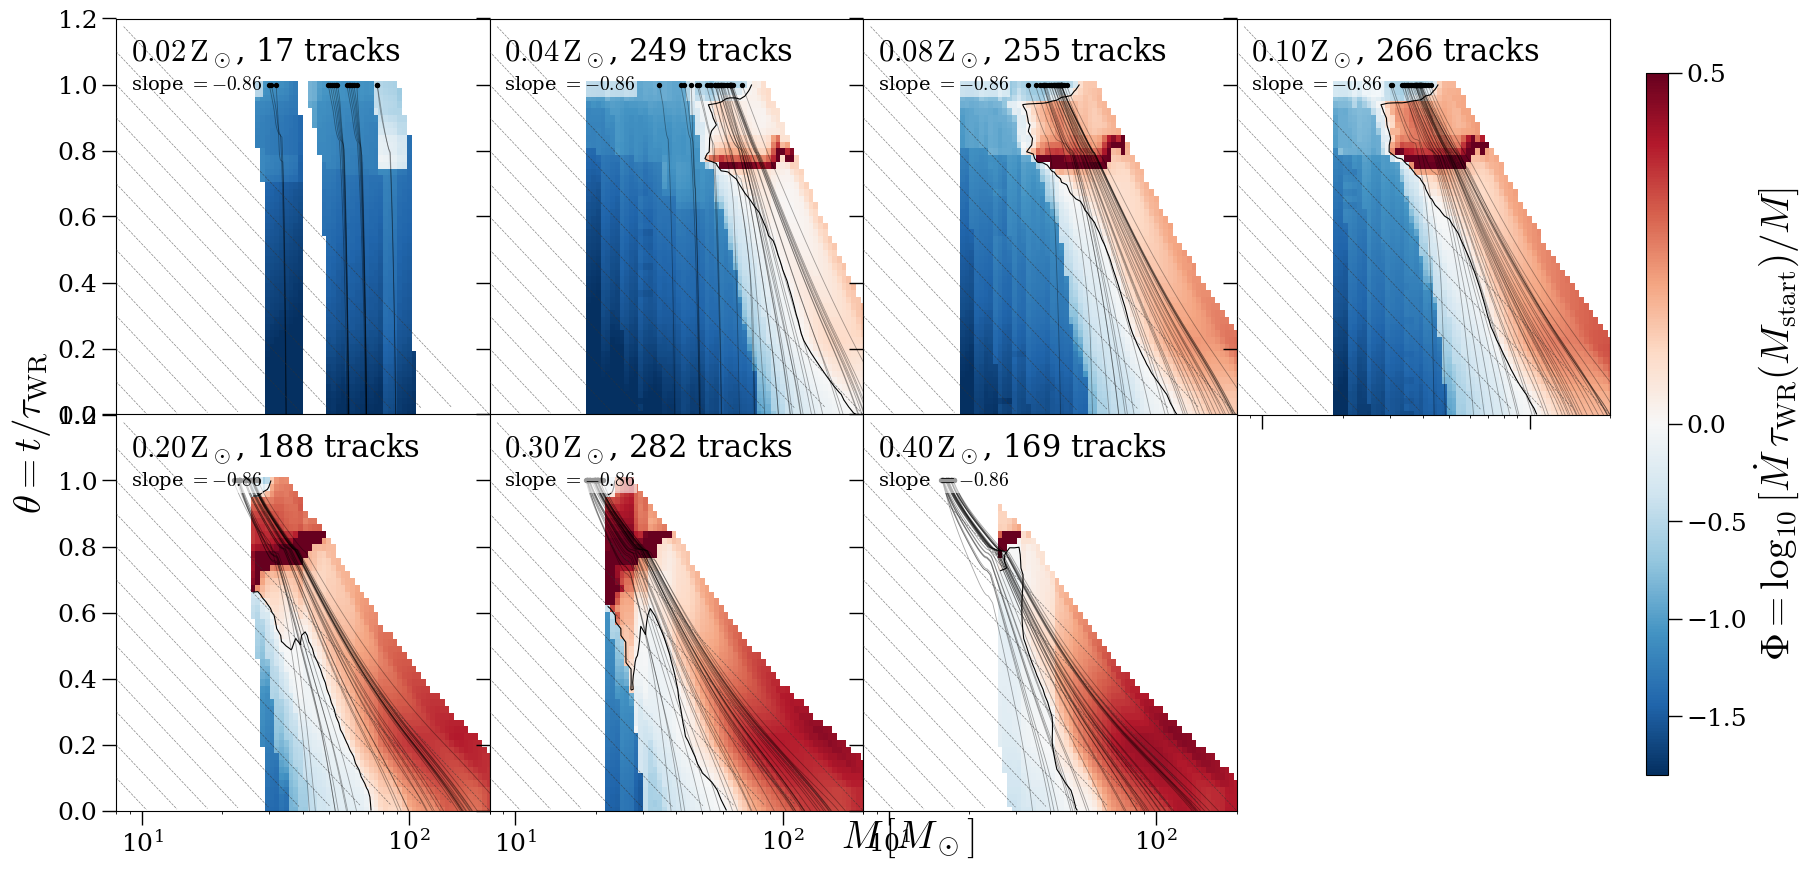

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


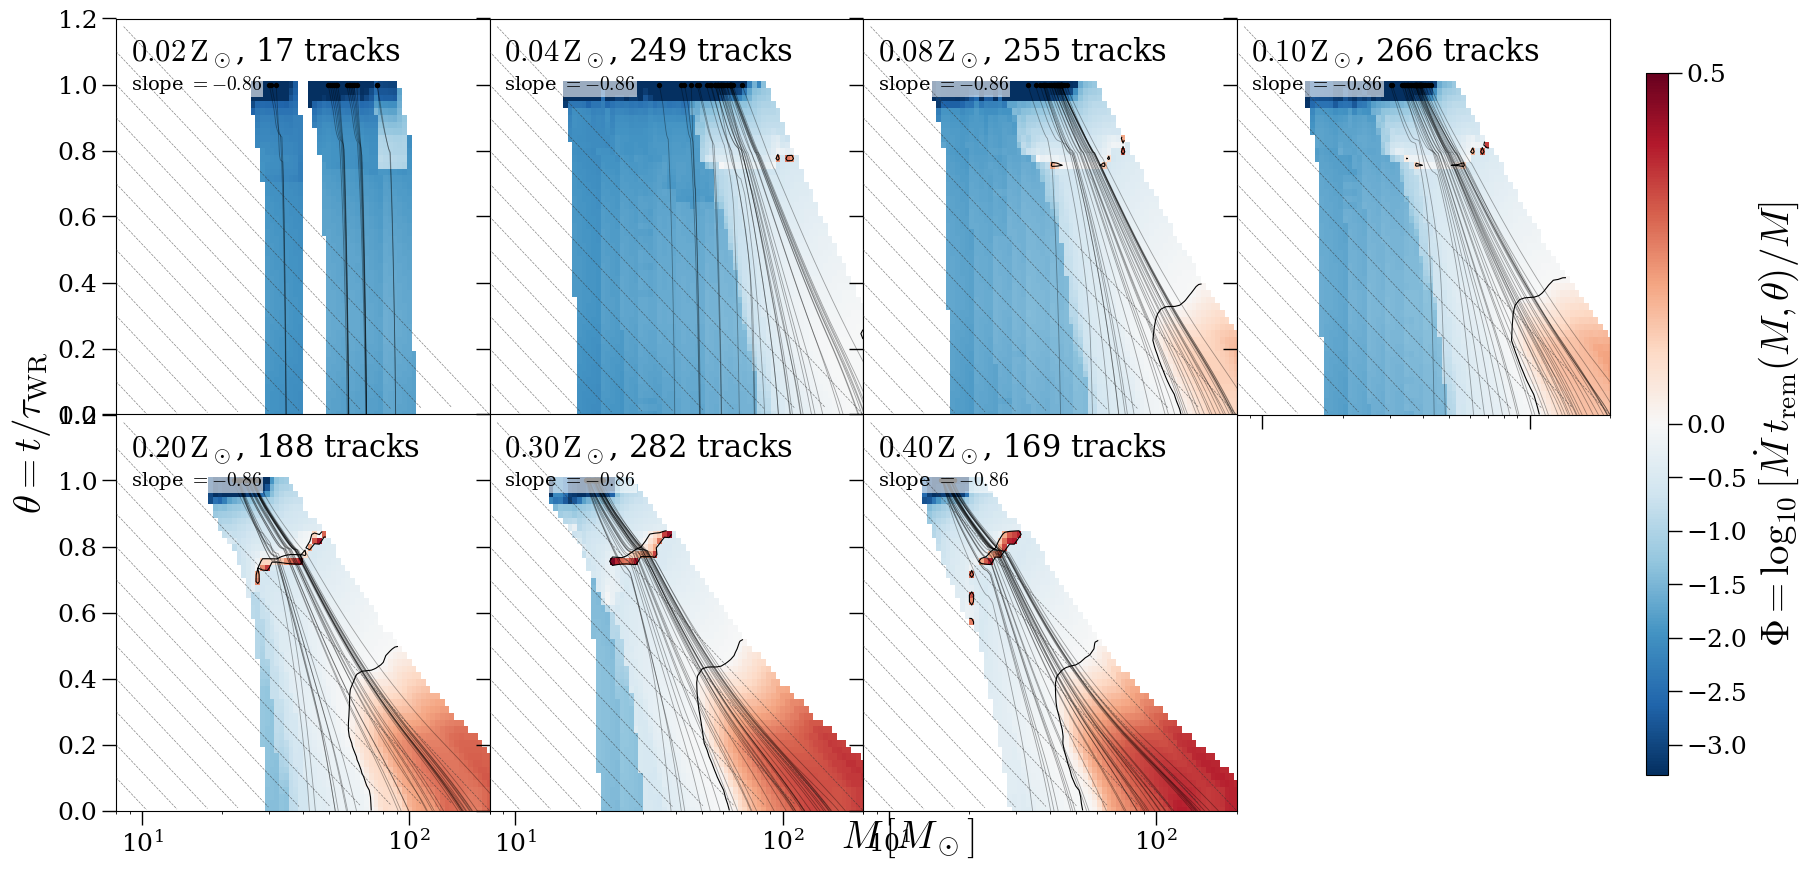

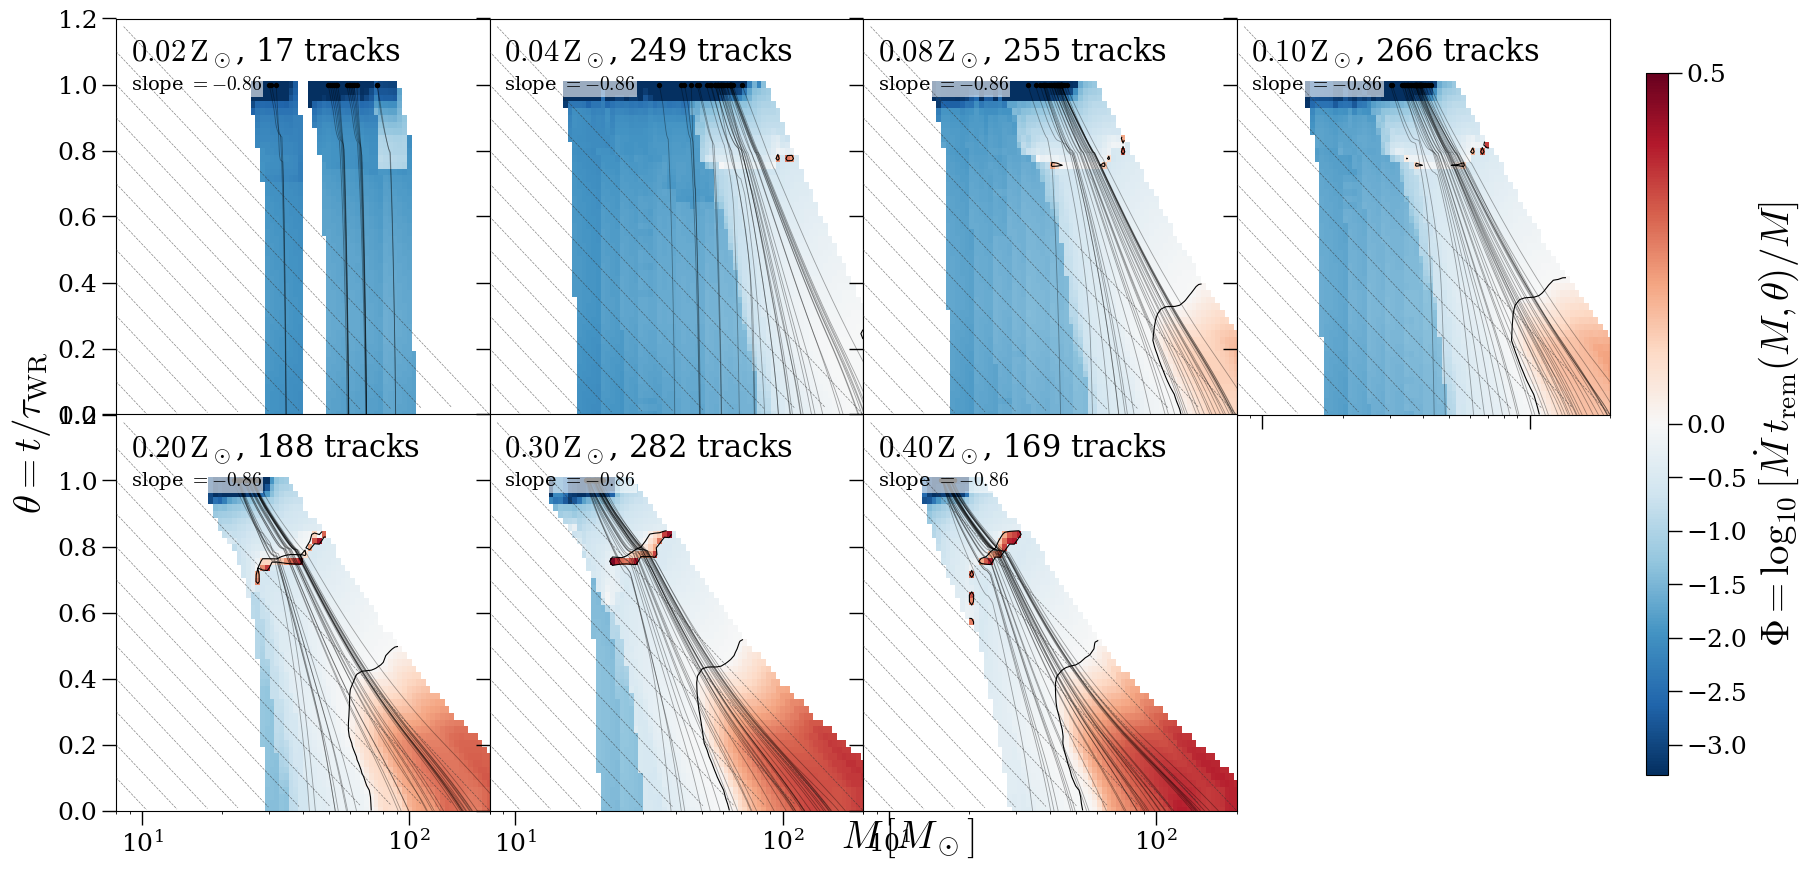

In [9]:
def phi_field_and_panels(z_keys=Z_KEYS, ncols=4, M_lo=8, M_hi=200, n_M=80, n_theta=50, save=True, timescale='tau_WR_start', slope='auto', dlogM_step=None):
    nrows = int(np.ceil(len(z_keys) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 9),
                             sharex=True, sharey=True,
                             gridspec_kw={'wspace': 0, 'hspace': 0}, squeeze=False)
    axes_flat = axes.flatten()
    M_grid = np.geomspace(M_lo, M_hi, n_M)
    theta_grid = np.linspace(0, 1, n_theta)

    # 1st pass: compute Phi for all panels
    Phi_per_z = {}
    for z_key in z_keys:
        tracks = TRACKS.get(z_key, [])
        if not tracks: continue
        Z_abs = float(z_key) * ZSUN_LOC
        rels = hems_relations(tracks, M_grid, theta_grid, dlogM=0.07, dtheta=0.06, min_pts=2)
        if rels is None: continue
        L_g, T_g, X_g = rels
        if timescale == 'tau_WR_start':
            # Multiplier is tau_WR(M_inst) using WR-onset masses; no theta dependence,
            # but the field stops at the smallest WR-onset mass on grid (~20 Msun).
            tau_M = tau_wr_from_tracks(tracks, M_grid, dlogM=0.12, min_pts=2)
            T_field = np.broadcast_to(tau_M, (n_theta, n_M))
        elif timescale == 't_rem_inst':
            # Multiplier is the literal remaining time t_rem = tau_WR - t binned by
            # (M_inst, theta); populates low-M bins reached only mid-trajectory.
            T_field = t_rem_grid(tracks, M_grid, theta_grid, dlogM=0.07, dtheta=0.06, min_pts=2)
            if T_field is None: continue
        else:
            raise ValueError(timescale)
        Phi = np.full((n_theta, n_M), np.nan)
        for j, mm in enumerate(M_grid):
            for i in range(n_theta):
                tw = T_field[i, j]
                if not np.isfinite(tw) or tw <= 0: continue
                L = L_g[i,j]; T = T_g[i,j]; X = X_g[i,j]
                if not (np.isfinite(L) and np.isfinite(T) and np.isfinite(X)): continue
                w = che_wind(mm, L, T, X, Z_abs)
                if w <= 0: continue
                Phi[i,j] = np.log10(w * tw / mm + 1e-30)
        Phi_per_z[z_key] = Phi

    # common color range
    all_vals = np.concatenate([P[np.isfinite(P)].ravel() for P in Phi_per_z.values()]) if Phi_per_z else np.array([0.0])
    if all_vals.size:
        vmin, vmax = np.nanpercentile(all_vals, [2, 98])
    else:
        vmin, vmax = -3, 1
    vmin = min(vmin, -1.0); vmax = max(vmax, 0.5)
    norm = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)

    last_im = None
    for ax_i, z_key in enumerate(z_keys):
        ax = axes_flat[ax_i]
        Phi = Phi_per_z.get(z_key)
        tracks = TRACKS.get(z_key, [])
        if Phi is not None:
            im = ax.pcolormesh(M_grid, theta_grid, Phi, cmap='RdBu_r', norm=norm, shading='auto')
            last_im = im
            # contour at the transition
            try:
                ax.contour(M_grid, theta_grid, Phi, levels=[0.0], colors='k', linewidths=0.8)
            except Exception:
                pass
        # overlay MESA trajectories
        step = max(1, len(tracks)//30)
        for tr in tracks[::step]:
            ax.plot(tr['M'], tr['t']/tr['tau_WR'], color='k', alpha=0.35, lw=0.6)
            ax.scatter(tr['M'][-1], 1.0, color='k', s=8, zorder=3)
        ax.set_xscale('log')
        ax.set_xlim(M_lo, M_hi); ax.set_ylim(0, 1.2)
        ax.text(0.04, 0.96, rf'${float(z_key):.2f}\,\mathrm{{Z}}_\odot$, {len(tracks)} tracks',
                transform=ax.transAxes, ha='left', va='top', fontsize=22,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))
    for j in range(len(z_keys), len(axes_flat)):
        axes_flat[j].axis('off')

    # Optional dashed parallel lines of constant slope dtheta/dlog10(M).
    if slope is not None:
        x0, x1 = M_lo, M_hi
        y0, y1 = 0.0, 1.2
        # Default slope: -(y_width)/(x_width_in_log10) — diagonal across the panel,
        # signed negative since trajectories descend in M as theta grows.
        if isinstance(slope, str) and slope == 'auto':
            slope_val = -(y1 - y0) / (np.log10(x1) - np.log10(x0))
        else:
            slope_val = float(slope)
        # Default dlogM_step: 1/12 of the x-range in log10.
        if dlogM_step is None:
            dlogM_step_val = (np.log10(x1) - np.log10(x0)) / 12.0
        else:
            dlogM_step_val = float(dlogM_step)
        # Family of intercepts: pick logM anchors stepping by dlogM_step from the
        # left edge, but also extend leftward so lines cover the full panel.
        # A line is theta = slope*(logM - logM_anchor) + theta_anchor=0; the line
        # crosses theta=0 at logM = logM_anchor and theta=y1 at logM_anchor + y1/slope.
        # To cover the whole panel: anchors must span [logM_min - y1/|slope|, logM_max].
        lm_min = np.log10(x0); lm_max = np.log10(x1)
        if slope_val != 0:
            extend = abs((y1 - y0) / slope_val)
        else:
            extend = 0.0
        first = lm_min - extend
        anchors = np.arange(first, lm_max + dlogM_step_val, dlogM_step_val)
        for ax_i in range(len(z_keys)):
            ax = axes_flat[ax_i]
            for la in anchors:
                # parametrise by x = log10(M) over [lm_min, lm_max]
                xs = np.linspace(lm_min, lm_max, 50)
                ys = slope_val * (xs - la)
                m = (ys >= y0) & (ys <= y1)
                if m.sum() < 2: continue
                ax.plot(10.0**xs[m], ys[m], color='0.2', lw=0.5, ls='--', alpha=0.6, zorder=4)
            # add slope value to panel title region (small text under z label)
            ax.text(0.04, 0.86, rf'slope $= {slope_val:.2f}$',
                    transform=ax.transAxes, ha='left', va='top', fontsize=14,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1.0))

    # single colorbar on the right
    cbar_ax = fig.add_axes([0.91, 0.12, 0.012, 0.78])
    if last_im is not None:
        _lbl = r'$\Phi=\log_{10}[\dot M\,\tau_\mathrm{WR}(M_\mathrm{start})/M]$' if timescale=='tau_WR_start' else r'$\Phi=\log_{10}[\dot M\,t_\mathrm{rem}(M,\theta)/M]$'
        fig.colorbar(last_im, cax=cbar_ax, label=_lbl)
    fig.text(0.5, 0.025, r'$M\,[M_\odot]$', ha='center', va='bottom')
    fig.text(0.025, 0.5, r'$\theta=t/\tau_\mathrm{WR}$', ha='right', va='center', rotation=90)
    fig.subplots_adjust(left=0.06, right=0.89, bottom=0.08, top=0.96)
    if save:
        _slope_tag = '' if slope is None else (f"_slope{slope:+.2f}" if not isinstance(slope, str) else '_slopeauto')
        savefig(fig, f'phi_panels_perZ_{timescale}{_slope_tag}')
    plt.show()
    return fig

phi_field_and_panels(timescale='tau_WR_start')
phi_field_and_panels(timescale='t_rem_inst')


**Reading the panels (per metallicity).**

- Red region ($\Phi>0$): the wind would remove **more** than the current mass within the remaining WR lifetime — the star drifts strongly downward in $M$.
- Blue region ($\Phi<0$): the wind cannot significantly modify the mass within the remaining lifetime — trajectories are nearly horizontal.
- Black contour ($\Phi=0$): the instantaneous fixed point where wind timescale equals remaining lifetime.

Trajectories should drift from red into the contour; their endpoints should sit on or near the contour at $t\to\tau_\mathrm{WR}$. The mass coordinate of that crossing **is** the pile-up mass $M_*(Z)$, and it is determined entirely by (i) the wind recipe `che_wind` (`run_star_extras.f90`) and (ii) the He-MS structure relations $L, T_\mathrm{eff}, X(M,\theta,Z)$ extracted from MESA histories — with **no parameter tuned to land at 35**.


**Reading the second variant** (`timescale='t_rem_inst'`).

The two calls produce panels with the same axes but a different normalising timescale:

- *First variant* (`tau_WR_start`) — multiplies $\dot M(M,\theta,Z)$ by $\tau_\mathrm{WR}(M_\mathrm{start})$, the typical WR-phase duration of stars whose **WR-onset mass** equals the current $M$. The map has no $\theta$ dependence in the multiplier and stops at the smallest WR-onset mass on the grid (~20 $M_\odot$), because no MESA track *began* its WR phase below that.
- *Second variant* (`t_rem_inst`) — multiplies by $t_\mathrm{rem}(M,\theta) = \tau_\mathrm{WR}-t$ binned over $(M_\mathrm{inst},\theta)$ samples from every track. Because tracks **pass through** every mass between WR onset and final mass, the field extends down to the lowest mass any track reaches (~10 $M_\odot$ or below), which is the regime your final-mass distribution actually occupies.

Reading rules:

- **Top edge ($\theta\to 1$) goes deep blue regardless of $M$**: $t_\mathrm{rem}\to 0$ forces $\Phi\to-\infty$. The contour $\Phi=0$ therefore curves up-and-leftward at high $\theta$ (red shrinks toward smaller $M$ as time runs out).
- **Bottom edge ($\theta\to 0$)** is essentially the same physical field as the first variant, since $t_\mathrm{rem}\approx\tau_\mathrm{WR}$ at the start.
- **Trajectory geometry is identical** in both panels — only the background changes. So if you saw two disconnected blue patches in the first variant, they are still there in the second, but now extending down to the actual endpoint masses, which makes the two-population structure easier to read off.
- **The dashed reference lines** are drawn with the same slope on both variants. Use them to read off the empirical $\theta$-vs-$\log M$ slopes of the two track families and feed the threshold into the splitter (next section).


### III.6b Splitting the population by WR-phase slope

After visually picking a threshold slope $b_*$ from the panels above (lines are parametrised as $\theta = b\,\log_{10}M + a$), call the splitter:

```python
slope_dict = compute_wr_slope_per_track(TRACKS)
core_with_slope = add_wr_slope_column(core, slope_dict)
df_steep, df_shallow = split_by_wr_slope(core_with_slope, threshold=-0.7)
```

`df_steep` collects runs whose $\theta(\log M)$ slope is more negative than the threshold (i.e., faster mass loss per dex of mass shed); `df_shallow` collects the rest. Inspect each subset's distributions to characterise the two populations.


In [10]:
core_props_df


,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_cdepl,m_odepl,m_f,m_hecore_zams,...,gamma1_w_avg_f,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_O_depleted,is_crash
0,0.0400,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,True,True,True,True,False,False,False,False,False
1,0.0400,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,True,True,True,True,False,False,False,False,False
2,0.0400,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,True,True,True,True,False,False,False,False,False
3,0.0400,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,True,True,True,True,False,False,False,False,False
4,0.0400,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5354,0.1000,70.0,69.543842,52.073465,45.280206,34.055044,33.991031,45.367180,33.991031,0.0,...,1.374279,True,False,False,False,True,True,True,False,False
5355,0.1000,240.0,238.517519,118.111748,51.497491,38.487440,38.405187,51.649113,38.405186,0.0,...,1.369410,True,False,False,False,True,True,True,False,False
5356,0.1000,70.0,69.560198,52.371847,43.706617,33.399946,33.339788,43.783871,33.339783,0.0,...,1.374856,True,False,False,False,True,True,True,False,False
5357,0.1000,70.0,69.567214,52.280721,43.246115,33.213740,33.156745,43.321859,33.152725,0.0,...,1.375098,True,False,False,False,True,True,True,False,False


In [11]:
slope_dict = compute_wr_slope_per_track(TRACKS)
core_with_slope = add_wr_slope_column(core_props_df, slope_dict)
print('rows with slope:', core_with_slope['wr_slope'].notna().sum(), '/', len(core_with_slope))
print(core_with_slope['wr_slope'].describe())

# Example threshold — replace with the value read off the panels.
THRESHOLD = -0.7
df_steep, df_shallow = split_by_wr_slope(core_with_slope, THRESHOLD)
print(f'steep (slope < {THRESHOLD}): {len(df_steep)} rows')
print(f'shallow (slope >= {THRESHOLD}): {len(df_shallow)} rows')


rows with slope: 1426 / 5359
count    1426.000000
mean       -2.182338
std         1.765961
min       -23.333538
25%        -2.308305
50%        -1.743655
75%        -1.390517
max        -1.004321
Name: wr_slope, dtype: float64
steep (slope < -0.7): 1426 rows
shallow (slope >= -0.7): 0 rows


---

## Part IV — Robustness across wind variants

The non-fine-tuning argument is: if the pile-up mass $M_*(Z)$ moves only modestly under the empirical uncertainties in the wind recipe and structure response, then 35 is a *robust* prediction, not a coincidence. The grid variants 02–12 sample exactly that uncertainty:

| Variant | Knob | Effect |
|---|---|---|
| 02 weak winds  | $\dot M_r \times 0.1$ | tests $\dot M_r$ normalisation |
| 03 strong winds | $\dot M_r \times 10$  | tests $\dot M_r$ normalisation |
| 04/05 flat/steep $M$-winds | $\beta = \mp 0.5$ | tests He-rich M-scaling |
| 06/07 flat/steep $Z$-winds | $\gamma = \mp 0.2$ | tests He-rich Z-scaling |
| 08/09 late/early WR transition | $X_0 = 0.5/0.7$ | tests He-poor→rich crossover |
| 10/11 inefficient/efficient mixing | $D_\mathrm{ES}\times 0.5/2$ | tests rotational-mixing efficiency |
| 12 steeper $M$-winds | $\beta = +1.0$ | extreme $\beta$ |

For variants 02, 03, 04, 05, 06, 07 only the wind multiplicative pieces change — these can be evaluated by **rerunning the Python `che_wind` with the corresponding `(beta_extra, gamma_extra, mdot_r_extra)`** *while reusing the fiducial He-MS structure relations* (because for these variants the wind change is small enough that the structure response is approximately the fiducial one to first order — a deliberate approximation, validated by the MESA endpoints from the variant grids when those are available).


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


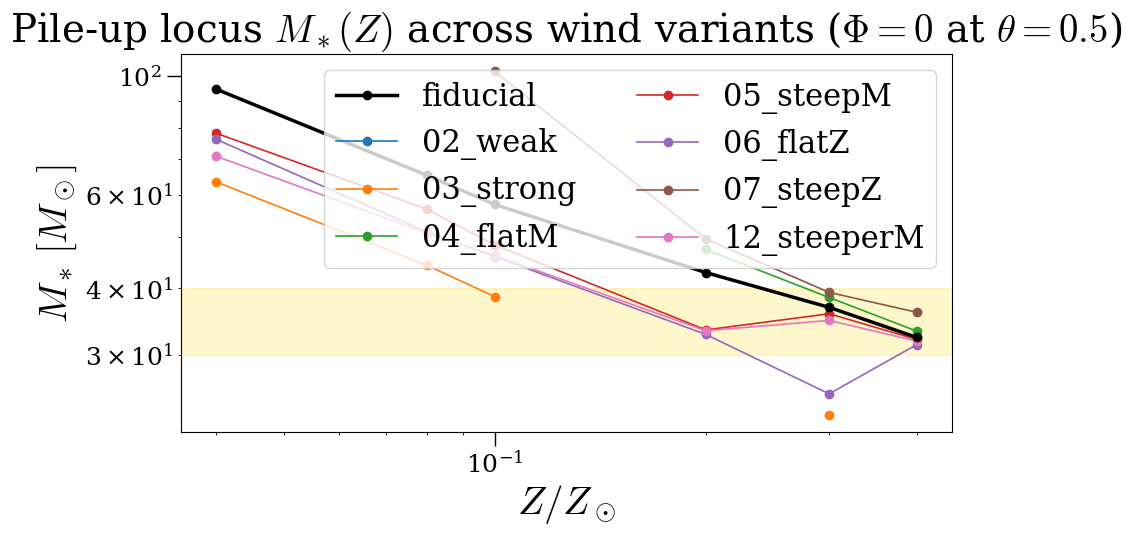

        fiducial  02_weak  03_strong  04_flatM  05_steepM  06_flatZ  \
Z/Zsun                                                                
0.0200       NaN      NaN        NaN       NaN        NaN       NaN   
0.0400      94.7      NaN       63.4       NaN       78.3      76.2   
0.0800      65.2      NaN       44.2       NaN       56.4      51.1   
0.1000      57.5      NaN       38.6       NaN       48.3      45.9   
0.2000      42.9      NaN        NaN      47.3       33.4      32.8   
0.3000      36.9      NaN       23.2      38.5       35.9      25.4   
0.4000      32.4      NaN        NaN      33.3       32.1      31.4   

        07_steepZ  12_steeperM  
Z/Zsun                          
0.0200        NaN          NaN  
0.0400        NaN         70.9  
0.0800        NaN         50.8  
0.1000      102.1         46.1  
0.2000       49.6         33.3  
0.3000       39.3         34.8  
0.4000       36.1         31.9  


In [12]:
# Variant wind-knob mapping (from CLAUDE.md §3.1)
WIND_VARIANTS = {
    'fiducial':  dict(mdot_r_extra=1.0,  beta_extra=0.0, gamma_extra=0.0, X0=0.6, dX=0.3),
    '02_weak':   dict(mdot_r_extra=0.1,  beta_extra=0.0, gamma_extra=0.0, X0=0.6, dX=0.3),
    '03_strong': dict(mdot_r_extra=10.0, beta_extra=0.0, gamma_extra=0.0, X0=0.6, dX=0.3),
    '04_flatM':  dict(mdot_r_extra=1.0,  beta_extra=-0.5, gamma_extra=0.0, X0=0.6, dX=0.3),
    '05_steepM': dict(mdot_r_extra=1.0,  beta_extra=+0.5, gamma_extra=0.0, X0=0.6, dX=0.3),
    '06_flatZ':  dict(mdot_r_extra=1.0,  beta_extra=0.0, gamma_extra=-0.2, X0=0.6, dX=0.3),
    '07_steepZ': dict(mdot_r_extra=1.0,  beta_extra=0.0, gamma_extra=+0.2, X0=0.6, dX=0.3),
    '12_steeperM': dict(mdot_r_extra=1.0, beta_extra=+1.0, gamma_extra=0.0, X0=0.6, dX=0.3),
}


# Cache the per-Z fiducial structure relations once
M_grid_var = np.geomspace(8, 200, 120)
theta_grid_var = np.linspace(0, 1, 21)
HEMS_CACHE = {}
TAUWR_CACHE = {}
for z_key in Z_KEYS:
    tr = TRACKS.get(z_key, [])
    if not tr:
        HEMS_CACHE[z_key] = None; TAUWR_CACHE[z_key] = None; continue
    HEMS_CACHE[z_key] = hems_relations(tr, M_grid_var, theta_grid_var, dlogM=0.07, dtheta=0.06, min_pts=2)
    TAUWR_CACHE[z_key] = tau_wr_from_tracks(tr, M_grid_var, dlogM=0.12, min_pts=2)


def m_star_locus(z_key, variant_kw):
    # M where w * tau_WR / M = 1 (Phi=0) at theta=0.5, using cached fiducial relations.
    rels = HEMS_CACHE.get(z_key); tau_M = TAUWR_CACHE.get(z_key)
    if rels is None or tau_M is None: return np.nan
    L_g, T_g, X_g = rels
    Z_abs = float(z_key) * ZSUN_LOC
    k_mid = len(theta_grid_var) // 2
    Phi_M = np.full(M_grid_var.size, np.nan)
    for j, mm in enumerate(M_grid_var):
        if not np.isfinite(tau_M[j]) or tau_M[j] <= 0: continue
        L, T, X = L_g[k_mid,j], T_g[k_mid,j], X_g[k_mid,j]
        if not all(np.isfinite([L,T,X])): continue
        try:
            w = che_wind(mm, L, T, X, Z_abs, **variant_kw)
        except Exception:
            continue
        if w <= 0: continue
        Phi_M[j] = np.log10(w * tau_M[j] / mm + 1e-30)
    fin = np.isfinite(Phi_M)
    if fin.sum() < 3: return np.nan
    Mf = M_grid_var[fin]; Pf = Phi_M[fin]
    crosses = np.where(np.diff(np.sign(Pf)) != 0)[0]
    if not crosses.size: return np.nan
    i0 = crosses[-1]  # right-most crossing = pile-up
    f = -Pf[i0] / (Pf[i0+1] - Pf[i0])
    return Mf[i0] * (Mf[i0+1]/Mf[i0])**f


results = {v: [m_star_locus(z, kw) for z in Z_KEYS] for v, kw in WIND_VARIANTS.items()}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for vname, mvals in results.items():
    is_fid = (vname == 'fiducial')
    ax.plot(Z_DIV_ZSUN, mvals, marker='o', label=vname,
            color='k' if is_fid else None,
            lw=2.5 if is_fid else 1.2,
            zorder=3 if is_fid else 2)
ax.axhspan(30, 40, color='gold', alpha=0.2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$Z/Z_\odot$'); ax.set_ylabel(r'$M_*\,[M_\odot]$')
ax.set_title(r'Pile-up locus $M_*(Z)$ across wind variants ($\Phi=0$ at $\theta=0.5$)')
ax.legend(ncol=2, loc='best')
fig.tight_layout()
savefig(fig, 'mstar_variants')
plt.show()

import pandas as pd
df_mstar = pd.DataFrame(results, index=Z_KEYS)
df_mstar.index.name = 'Z/Zsun'
print(df_mstar.round(1))


### IV.2 The non-fine-tuning statement

If the table above shows $M_*(Z\sim 0.1\!-\!0.2)$ remaining within $\sim 25-50\,M_\odot$ across all variants 02–12, then the 35 prediction is *robust* against the empirically-allowed range of wind physics: not fine-tuning, but the natural fixed point of two independently-calibrated ingredients (a wind recipe stitched from Vink/Bjorklund/Krticka/Sander and MESA's standard structure response).

A residual variation of $\sim\pm 10\,M_\odot$ across variants is still a *prediction*, and it becomes the dominant theoretical uncertainty in the location of the predicted peak — not a free parameter to tune. The strength of this argument depends on:

1. The contraction Jacobian (Part II) staying $\ll 1$ across variants — the *mechanism* is robust even if $M_*$ shifts.
2. The variant grids (when available in `core_props_df` for variants 02–12 — currently sparse, only ZN 2,5,8) showing endpoint clouds consistent with the predicted $M_*(Z)$. Add this overlay when the variant data are loaded.


---

## Appendix

### A1. Optional comparison to the analytical toy

The nb70_REWRITE power-law model gives $\mathrm{d}m_i/\mathrm{d}m_f$ in closed form. Its purpose here is conceptual (it makes the contraction conditions explicit in $\alpha,\beta,\gamma$); all quantitative claims in Parts II–IV use raw MESA only. The toy is *not* used to argue for any specific $M_*$.

### A2. Wind recipe — open issues

`src/winds.py` does not currently include `vink2001`, `krticka2024`, `vink2011`, or the full `che_wind` blender. We carried our own transcription above. See `WIND_CORRECTIONS.md` for a list of fixes to apply to `src/winds.py` so that future code can call a single `che_wind(...)` matching MESA exactly.
